In [96]:
import sys
import warnings
warnings.filterwarnings('ignore')
from tqdm import tqdm

import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error as mae, mean_squared_error as mse

import statsmodels.formula.api as smf
import statsmodels.tsa.api as smt
import statsmodels.api as sm
import scipy.stats as scs
from scipy.optimize import minimize

import matplotlib.pyplot as plt


In [97]:
# reading dataset

df = pd.read_excel("Данные по регионам\\region 0.xlsx", parse_dates=["Date"])
consumption = df["consumption 0"]

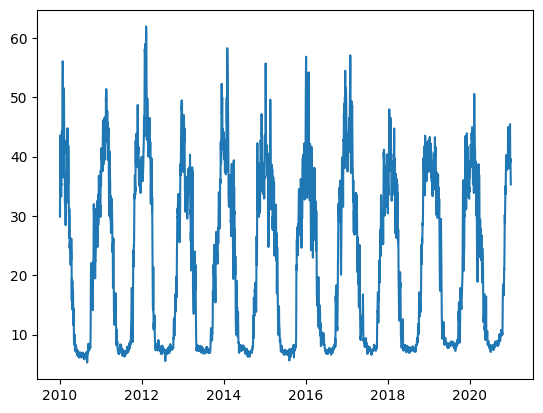

In [3]:
plt.plot(df["Date"], consumption)

In [12]:
def plotMovingAverage(series, n):

    """
    series - dataframe with timeseries
    n - rolling window size 

    """

    rolling_mean = series.rolling(window=n).mean()

    
    rolling_std =  series.rolling(window=n).std()
    upper_bond = rolling_mean+1.96*rolling_std
    lower_bond = rolling_mean-1.96*rolling_std

    plt.figure(figsize=(15,5))
    plt.title("Moving average\n window size = {}".format(n))
    plt.plot(rolling_mean, "g", label="Rolling mean trend")

    plt.plot(upper_bond, "r--", label="Upper Bond / Lower Bond")
    plt.plot(lower_bond, "r--")
    plt.plot(series[n:], label="Actual values")
    plt.legend(loc="upper left")
    plt.grid(True)

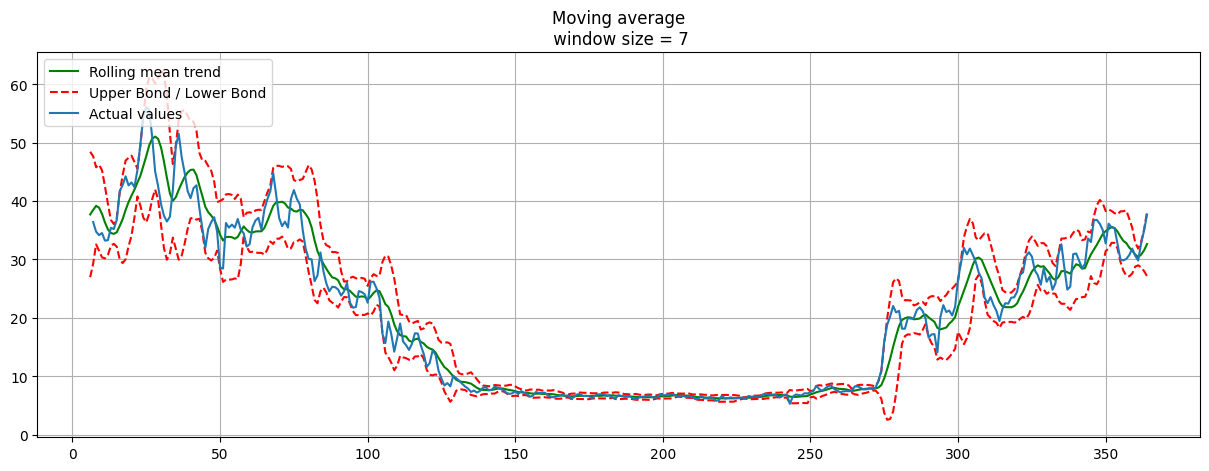

In [18]:
plotMovingAverage(consumption[:365], 7)

In [98]:
def check_series(series):
    test = sm.tsa.adfuller(series)
    print('adf: ', test[0])
    print('p-value: ', test[1])
    print('Critical values: ', test[4])
    if test[0]> test[4]['5%']: 
        print('есть единичные корни, ряд не стационарен')
    else:
        print('единичных корней нет, ряд стационарен')

In [99]:
check_series(consumption) # Если ряд стационарен, то d = 0 (порядок диффиренцирования)

adf:  -4.7894896120950134
p-value:  5.696050160835576e-05
Critical values:  {'1%': -3.431991624746321, '5%': -2.8622653800145192, '10%': -2.5671561276258172}
единичных корней нет, ряд стационарен


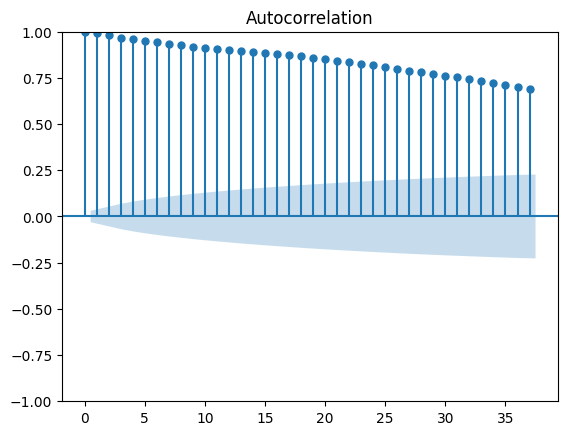

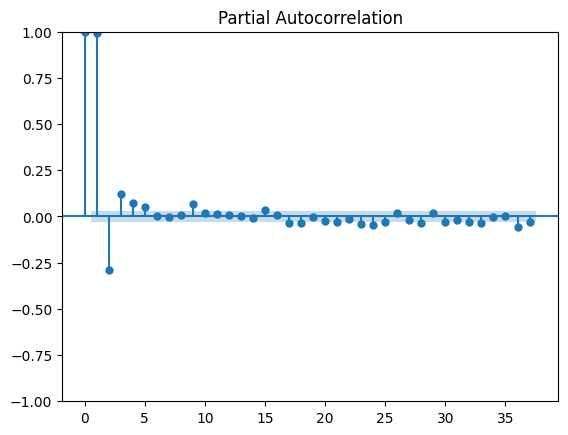

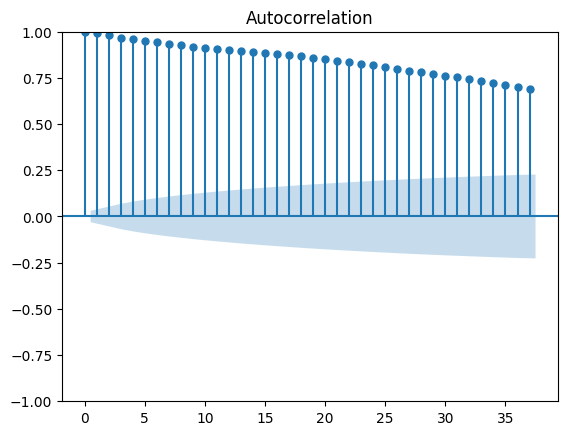

In [100]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf 

plot_pacf(consumption)
plot_acf(consumption)


In [ ]:
# По графику pacf порядок p = 2; q = 0, т.к. график acf экспоненциально уменьшается
# final order = (2, 0, 0) (1, 0, 0, 12)

In [101]:
df["Date"] = pd.to_datetime(df["Date"])


In [80]:
X_train, y_train, X_test, y_test = df.iloc[:1825, 2:], consumption[:1825], df.iloc[1825:, 2:], consumption[1825:] 

In [102]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(y_train, order=(2, 0, 0), seasonal_order=(1, 0, 0, 12), exog=X_train).fit()

In [103]:
X = df.iloc[:, 2:]

In [104]:
rmses = []
maes = []
predictions = []
lower_bounds = []
upper_bounds = []


for i in range(0, len(y_test)-30, 30):

    predicts = []
    confs = []

    for j in range(i, i+30):

        prediction = model.get_prediction(j, j+29, exog=X_test[j:j+30])
        rmse = np.sqrt(mse(y_test[j:j+30], prediction.prediction_results.forecasts.reshape(-1)))
        mae_error = mae(y_test[j:j+30], prediction.prediction_results.forecasts.reshape(-1))

        rmses.append(rmse)
        maes.append(mae_error)
        predicts.append(prediction.prediction_results.forecasts.reshape(-1))
        confs.append(prediction.conf_int())

    predictions.append(predicts[0])

    for k in np.array(confs[0]):
        lower_bounds.append(k[0])
        upper_bounds.append(k[1])

    model = SARIMAX(consumption[i+30:1825 + i + 30],  order=(2, 0, 0), seasonal_order=(1, 0, 0, 12), exog=X[i+30:1825 + i + 30]).fit()

    



ValueError: Provided exogenous values are not of the appropriate shape. Required (1, 2), got (30, 2).

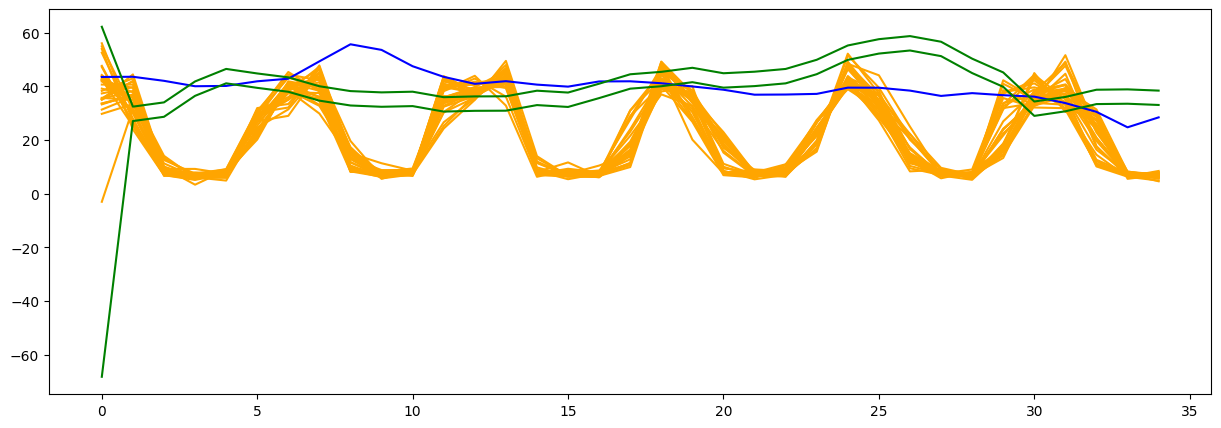

In [105]:
plt.figure(figsize=(15, 5))
plt.plot(predictions[:35], color="orange", label='predicted values')
plt.plot(np.array(y_test)[:35], color="blue", label='true values')
plt.plot(lower_bounds[:35], color="green", label='lower bound values')
plt.plot(upper_bounds[:35], color="green", label='upper bound values')
plt.show()

In [92]:
len(predictions)*7

35

In [93]:
predictions = np.array(predictions).flatten()

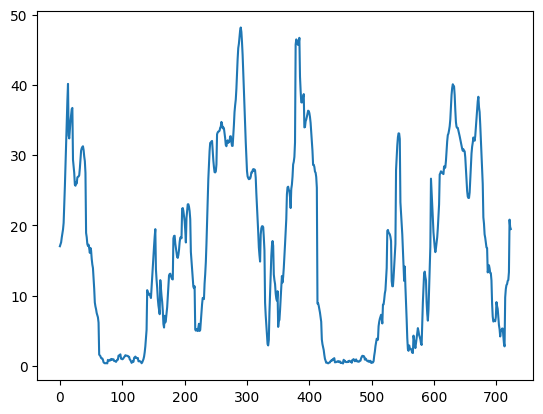

In [55]:
plt.plot(maes)

In [132]:
y_test[120:127]

1320    7.321527
1321    7.389407
1322    7.134976
1323    7.098057
1324    6.917942
1325    6.877586
1326    7.361543
Name: consumption 0, dtype: float64

In [17]:
model.predict(7, 14, exog=X_test[7:14])

7     37.430281
8     35.587144
9     35.153445
10    35.488415
11    33.297672
12    33.636533
13    33.697850
14    35.908661
Name: predicted_mean, dtype: float64

In [46]:
predict = model.get_prediction(120, 127)

In [48]:
np.array(predict.conf_int())

array([[ 8.84656667, 13.74683652],
       [ 8.81697594, 13.71724579],
       [11.20418985, 16.1044597 ],
       [ 9.65250419, 14.55277404],
       [ 6.97484302, 11.87511287],
       [ 6.68239808, 11.58266793],
       [ 6.56895726, 11.4692271 ],
       [ 5.87168007, 10.77194992]])

In [126]:
X_test[21:27]

,temperature 0,day type
1221,21.0,0
1222,21.0,0
1223,20.0,2
1224,20.0,3
1225,20.0,1
1226,21.0,1


In [128]:
y_test[21:27]

1221    7.915757
1222    7.934903
1223    7.972117
1224    7.971516
1225    8.190944
1226    7.836767
Name: consumption 0, dtype: float64

In [135]:
predict.conf_int()

,lower consumption 0,upper consumption 0
120,10.532968,15.891415
121,8.740072,14.098519
122,10.441889,15.800336
123,11.498552,16.856999
124,9.708546,15.066993
125,7.427866,12.786313
126,6.081035,11.439482
127,5.615462,10.973909
